# 景気ウォッチャー調査 分析レポート（data04）
**出典**: 景気ウォッチャー調査（内閣府）
**データ期間**: 2000年1月〜2026年2月
**分析日**: 2026年3月

## 調査概要
景気ウォッチャー調査は、地域の景気動向を肌で感じる立場にある人々（景気ウォッチャー）を対象に、
内閣府が毎月実施する月次調査。全国2,050人の景気ウォッチャーに対し、景気の現状・先行きを5段階で評価してもらい、
その加重平均としてDI（景気ウォッチャー指数）を算出。DI>50で景気回復、DI<50で景気後退を示す。

## セクション 0: セットアップ・ライブラリ読み込み

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import xlrd
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import japanize_matplotlib
from pathlib import Path
from IPython.display import display, Image

# パス設定
ROOT = Path('.')
DATA_DIR = ROOT / 'data04' / 'watcher5'
IMG_DIR = ROOT / 'data04' / 'レポート' / 'images'

# カラーパレット
COLORS = {
    '現状判断': '#1565C0',
    '先行き判断': '#E65100',
    '水準': '#2E7D32',
    '家計動向': '#1E88E5',
    '企業動向': '#F4511E',
    '雇用関連': '#43A047',
    '小売': '#7B1FA2',
    '飲食': '#D81B60',
    'サービス': '#00ACC1',
    '住宅': '#F9A825',
    '製造業': '#546E7A',
    '非製造業': '#8D6E63',
}
print('ライブラリ読み込み完了')
print(f'pandas: {pd.__version__}, xlrd: {xlrd.__VERSION__}')

ライブラリ読み込み完了
pandas: 2.3.3, xlrd: 2.0.2


## セクション 1: データ読み込みユーティリティ

In [2]:
def parse_fw_month(v):
    """全角日本語月を整数に変換"""
    s = str(v).replace('月', '').strip()
    fw = {'１':1,'２':2,'３':3,'４':4,'５':5,'６':6,
          '７':7,'８':8,'９':9,'１０':10,'１１':11,'１２':12}
    if s in fw:
        return fw[s]
    try:
        return int(float(s))
    except:
        return None


def load_watcher3():
    """watcher3.xls: 全国 分野・業種別DI推移 (2000-2026)"""
    path = DATA_DIR / 'watcher3.xls'
    wb = xlrd.open_workbook(str(path))
    col_map = {
        4: '合計', 5: '家計動向', 6: '小売', 15: '飲食', 16: 'サービス',
        21: '住宅', 22: '企業動向', 23: '製造業', 24: '非製造業', 25: '雇用'
    }
    results = {}
    sheet_labels = ['現状判断', '先行き判断', '水準']

    for idx, label in enumerate(sheet_labels):
        if idx >= wb.nsheets:
            continue
        ws = wb.sheet_by_index(idx)
        records, year = [], None
        for r in range(7, ws.nrows - 2):
            yv = str(ws.cell_value(r, 2)).strip()
            mv = ws.cell_value(r, 3)
            if yv and yv != '0.0' and '年' in yv:
                year = int(yv.replace('年', ''))
            elif yv and yv not in ('', '0.0'):
                try:
                    year = int(float(yv))
                except:
                    pass
            month = parse_fw_month(mv)
            if year is None or month is None:
                continue
            rec = {'year': year, 'month': month}
            for c, name in col_map.items():
                if c < ws.ncols:
                    v = ws.cell_value(r, c)
                    if isinstance(v, float) and v > 0:
                        rec[name] = round(v, 1)
            if '合計' in rec:
                records.append(rec)
        if records:
            df = pd.DataFrame(records)
            df['date'] = pd.to_datetime(
                df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2))
            df = df.set_index('date').drop(columns=['year','month']).sort_index()
            results[label] = df[~df.index.duplicated(keep='last')]
    return results


def load_watcher5():
    """watcher5.xls: 季節調整値DI (2002-2026)"""
    path = DATA_DIR / 'watcher5.xls'
    wb = xlrd.open_workbook(str(path))
    sector_cols = {3:'合計',4:'家計動向',5:'小売',6:'飲食',7:'サービス',
                   8:'住宅',9:'企業動向',10:'製造業',11:'非製造業',12:'雇用'}
    region_cols = {3:'全国',4:'北海道',5:'東北',6:'関東_計',7:'北関東',
                   8:'南関東',10:'甲信越',11:'東海',12:'北陸',13:'近畿',
                   14:'中国',15:'四国',16:'九州',17:'沖縄'}

    def parse_sheet(ws, col_map, data_start=6):
        records, year = [], None
        for r in range(data_start, ws.nrows - 1):
            yv = str(ws.cell_value(r, 1)).strip()
            mv = ws.cell_value(r, 2)
            if yv and yv != '0.0' and '年' in yv:
                year = int(yv.replace('年', ''))
            elif yv and yv not in ('', '0.0'):
                try:
                    year = int(float(yv))
                except:
                    pass
            try:
                month = int(float(str(mv)))
            except:
                month = None
            if year is None or month is None or not (1 <= month <= 12):
                continue
            rec = {'year': year, 'month': month}
            for c, name in col_map.items():
                if c < ws.ncols:
                    v = ws.cell_value(r, c)
                    if isinstance(v, float) and v > 0:
                        rec[name] = round(v, 1)
            if '合計' in rec or '全国' in rec:
                records.append(rec)
        if not records:
            return pd.DataFrame()
        df = pd.DataFrame(records)
        df['date'] = pd.to_datetime(
            df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2))
        df = df.set_index('date').drop(columns=['year','month']).sort_index()
        return df[~df.index.duplicated(keep='last')]

    results = {}
    if wb.nsheets > 0:
        results['分野別現状'] = parse_sheet(wb.sheet_by_index(0), sector_cols)
    if wb.nsheets > 1:
        results['分野別先行き'] = parse_sheet(wb.sheet_by_index(1), sector_cols)
    if wb.nsheets > 3:
        results['地域別現状'] = parse_sheet(wb.sheet_by_index(3), region_cols)
    if wb.nsheets > 4:
        results['地域別先行き'] = parse_sheet(wb.sheet_by_index(4), region_cols)
    return results


def load_watcher2_1():
    """watcher2-1.xls: 全国 回答者数・DI推移"""
    path = DATA_DIR / 'watcher2-1.xls'
    wb = xlrd.open_workbook(str(path))
    ws = wb.sheet_by_index(0)
    records = []
    for r in range(7, ws.nrows - 2):
        dv = ws.cell_value(r, 0)
        if not isinstance(dv, float) or dv < 30000:
            continue
        try:
            dt = xlrd.xldate_as_datetime(dv, 0)
        except:
            continue
        di_v = ws.cell_value(r, 13)
        if not isinstance(di_v, float):
            continue
        pct_cols = {'良くなっている':8, 'やや良くなっている':9, '変わらない':10,
                    'やや悪くなっている':11, '悪くなっている':12}
        rec = {'date': dt, 'DI': round(di_v, 1),
               '回答者数': int(ws.cell_value(r, 1)) if isinstance(ws.cell_value(r,1), float) else np.nan}
        for name, col in pct_cols.items():
            v = ws.cell_value(r, col)
            rec[name] = round(float(v), 1) if isinstance(v, float) else np.nan
        records.append(rec)
    df = pd.DataFrame(records).set_index('date').sort_index()
    return df[~df.index.duplicated(keep='last')]


# データ読み込み
w3 = load_watcher3()
w5 = load_watcher5()
w21 = load_watcher2_1()

print('=== データ読み込み完了 ===')
for k, df in w3.items():
    print(f'  watcher3[{k}]: {len(df)}行 ({df.index[0].strftime("%Y-%m")}〜{df.index[-1].strftime("%Y-%m")})')
for k, df in w5.items():
    if not df.empty:
        print(f'  watcher5[{k}]: {len(df)}行 ({df.index[0].strftime("%Y-%m")}〜{df.index[-1].strftime("%Y-%m")})')
print(f'  watcher2-1: {len(w21)}行 ({w21.index[0].strftime("%Y-%m")}〜{w21.index[-1].strftime("%Y-%m")})')

=== データ読み込み完了 ===
  watcher3[現状判断]: 314行 (2000-01〜2026-02)
  watcher3[先行き判断]: 314行 (2000-01〜2026-02)
  watcher3[水準]: 314行 (2000-01〜2026-02)
  watcher5[分野別現状]: 289行 (2002-01〜2026-01)
  watcher5[分野別先行き]: 289行 (2002-01〜2026-01)
  watcher5[地域別現状]: 289行 (2002-01〜2026-01)
  watcher5[地域別先行き]: 289行 (2002-01〜2026-01)
  watcher2-1: 302行 (2001-01〜2026-02)


## セクション 2: データ概要確認

In [3]:
# 直近データの確認
print('=== 直近6ヶ月の景気DI（現状判断）===')
df_recent = w3['現状判断'][['合計','家計動向','企業動向','雇用']].tail(6)
display(df_recent.rename(columns={'合計':'全体','家計動向':'家計動向関連','企業動向':'企業動向関連','雇用':'雇用関連'}))

print('\n=== 直近6ヶ月の回答者構成比（%）===')
pct_cols = ['良くなっている','やや良くなっている','変わらない','やや悪くなっている','悪くなっている','DI']
display(w21[pct_cols].tail(6).round(1))

=== 直近6ヶ月の景気DI（現状判断）===


,全体,家計動向関連,企業動向関連,雇用関連
date,,,,
2025-09-01,46.6,45.8,48.6,47.7
2025-10-01,48.5,47.8,50.8,48.7
2025-11-01,48.0,47.9,48.9,47.1
2025-12-01,48.5,48.4,49.2,48.2
2026-01-01,45.4,44.4,47.5,47.7
2026-02-01,48.2,47.7,49.4,48.9



=== 直近6ヶ月の回答者構成比（%）===


,良くなっている,やや良くなっている,変わらない,やや悪くなっている,悪くなっている,DI
date,,,,,,
2025-09-01,2.0,15.8,51.8,24.0,6.3,45.8
2025-10-01,1.1,10.6,71.5,15.6,1.1,48.7
2025-11-01,6.0,20.7,49.0,21.8,2.5,51.5
2025-12-01,2.8,20.4,48.4,24.2,4.2,48.4
2026-01-01,1.6,15.5,58.7,19.9,4.4,47.5
2026-02-01,0.0,13.7,69.1,16.0,1.1,48.9


In [4]:
# 統計サマリー
print('=== 現状判断DI（合計）統計サマリー ===')
s = w3['現状判断']['合計']
stats = pd.Series({
    '期間': f'{s.index[0].strftime("%Y-%m")}〜{s.index[-1].strftime("%Y-%m")}',
    'データ数': len(s),
    '平均': f'{s.mean():.1f}',
    '中央値': f'{s.median():.1f}',
    '最大': f'{s.max():.1f} ({s.idxmax().strftime("%Y-%m")})',
    '最小': f'{s.min():.1f} ({s.idxmin().strftime("%Y-%m")})',
    '標準偏差': f'{s.std():.1f}',
})
display(stats.to_frame('値'))

=== 現状判断DI（合計）統計サマリー ===


,値
期間,2000-01〜2026-02
データ数,314
平均,45.2
中央値,46.9
最大,58.6 (2021-12)
最小,9.5 (2020-04)
標準偏差,7.9


## セクション 3: 長期トレンド分析（2000年〜2026年）

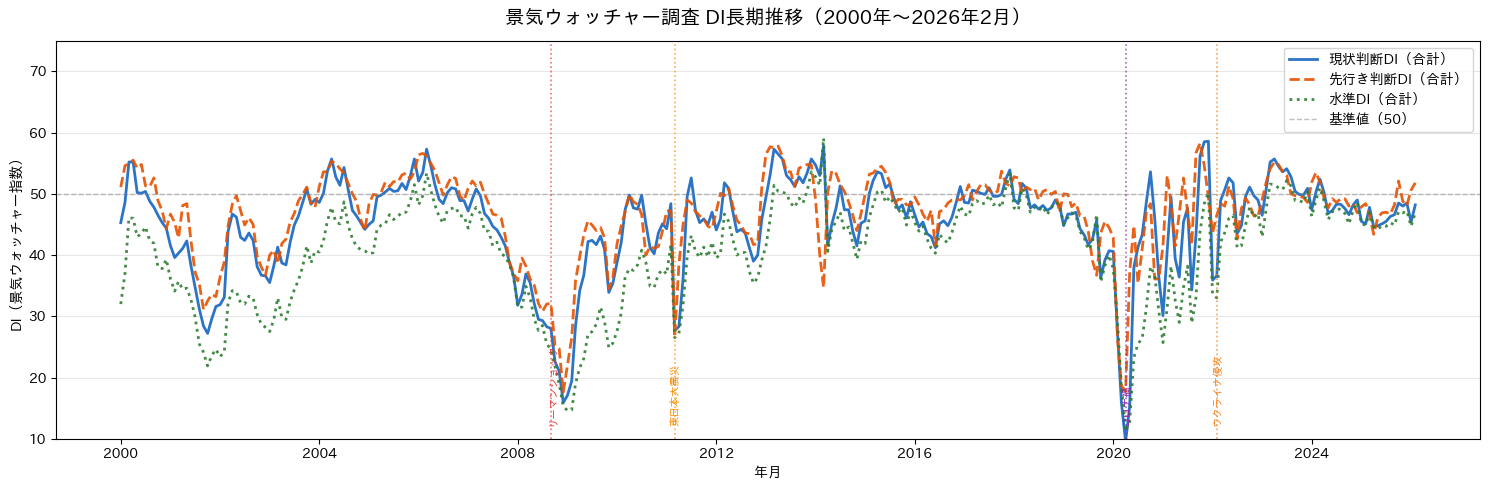

In [5]:
### 3-1. DI長期推移（現状・先行き・水準）
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1,1,1)

for label, color, ls in [
    ('現状判断', COLORS['現状判断'], '-'),
    ('先行き判断', COLORS['先行き判断'], '--'),
    ('水準', COLORS['水準'], ':'),
]:
    if label in w3 and '合計' in w3[label].columns:
        s = w3[label]['合計'].dropna()
        ax.plot(s.index, s.values, color=color, linestyle=ls, linewidth=2,
                label=f'{label}DI（合計）', alpha=0.9)

ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='基準値（50）')

events = [
    ('2008-09', 'リーマンショック', '#E53935'),
    ('2011-03', '東日本大震災', '#FB8C00'),
    ('2020-04', 'コロナ禍', '#8E24AA'),
    ('2022-02', 'ウクライナ侵攻', '#F57F17'),
]
for date_str, label, color in events:
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color=color, linewidth=1.2, linestyle=':', alpha=0.7)
    ax.text(dt, 12, label, fontsize=7.5, color=color, ha='center', va='bottom',
            rotation=90)

ax.set_title('景気ウォッチャー調査 DI長期推移（2000年〜2026年2月）',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('年月')
ax.set_ylabel('DI（景気ウォッチャー指数）')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(10, 75)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

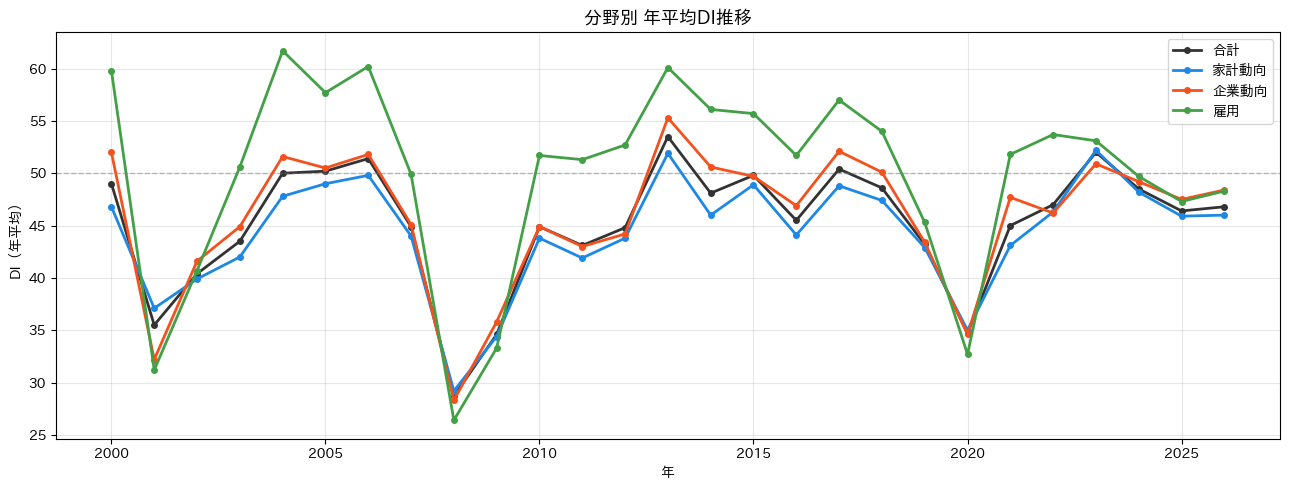


直近5年の年平均DI:


,全体,家計動向関連,企業動向関連,雇用関連
date,,,,
2022,47.0,46.3,46.2,53.7
2023,52.0,52.2,50.9,53.1
2024,48.5,48.2,49.2,49.7
2025,46.4,45.9,47.5,47.3
2026,46.8,46.0,48.4,48.3


In [6]:
### 3-2. 主要指標の年次推移（年平均DI）
df_annual = w3['現状判断'][['合計','家計動向','企業動向','雇用']].resample('YE').mean().round(1)
df_annual.index = df_annual.index.year

fig, ax = plt.subplots(figsize=(13, 5))
for col, color in [('合計','#333333'),('家計動向',COLORS['家計動向']),
                   ('企業動向',COLORS['企業動向']),('雇用',COLORS['雇用関連'])]:
    if col in df_annual.columns:
        ax.plot(df_annual.index, df_annual[col].values, marker='o', markersize=4,
                linewidth=2, color=color, label=col)

ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('分野別 年平均DI推移', fontsize=13, fontweight='bold')
ax.set_xlabel('年')
ax.set_ylabel('DI（年平均）')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 年次テーブル
print('\n直近5年の年平均DI:')
display(df_annual.tail(5).rename(columns={'合計':'全体','家計動向':'家計動向関連',
                                           '企業動向':'企業動向関連','雇用':'雇用関連'}))

## セクション 4: 分野別・業種別分析

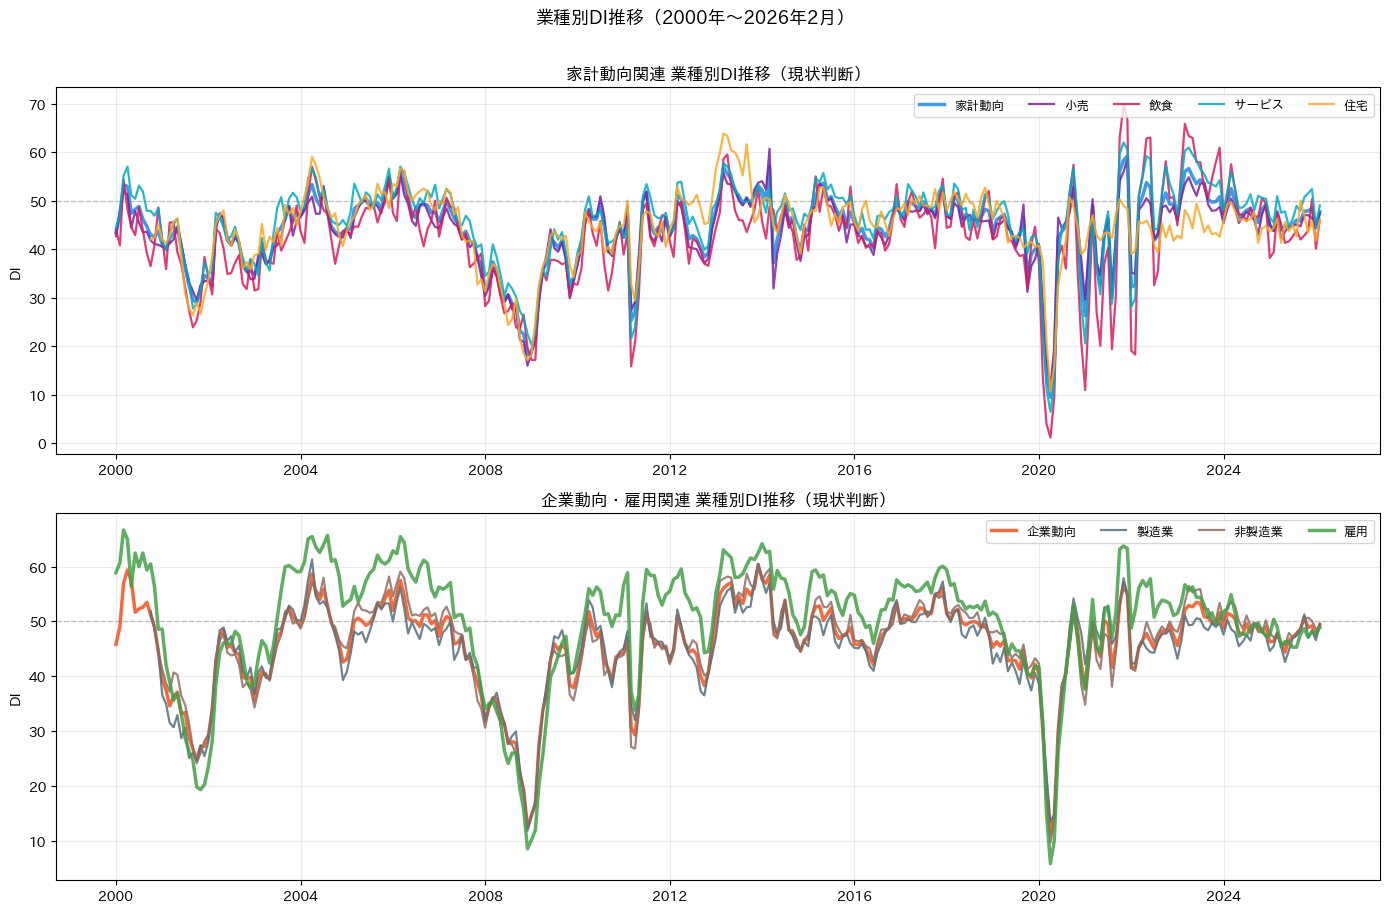

In [7]:
### 4-1. 家計動向関連業種別DI推移
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

df = w3['現状判断']

# 家計動向関連
ax = axes[0]
hh_cols = [('家計動向','#1E88E5',2.5), ('小売','#7B1FA2',1.6),
           ('飲食','#D81B60',1.6), ('サービス','#00ACC1',1.6), ('住宅','#F9A825',1.6)]
for col, color, lw in hh_cols:
    if col in df.columns:
        ax.plot(df.index, df[col].values, color=color, linewidth=lw, label=col, alpha=0.85)
ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.4)
ax.set_title('家計動向関連 業種別DI推移（現状判断）', fontsize=12, fontweight='bold')
ax.set_ylabel('DI')
ax.legend(loc='upper right', fontsize=9, ncol=5)
ax.grid(alpha=0.25)

# 企業動向・雇用
ax = axes[1]
biz_cols = [('企業動向','#F4511E',2.5), ('製造業','#546E7A',1.6),
            ('非製造業','#8D6E63',1.6), ('雇用','#43A047',2.5)]
for col, color, lw in biz_cols:
    if col in df.columns:
        ax.plot(df.index, df[col].values, color=color, linewidth=lw, label=col, alpha=0.85)
ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.4)
ax.set_title('企業動向・雇用関連 業種別DI推移（現状判断）', fontsize=12, fontweight='bold')
ax.set_ylabel('DI')
ax.legend(loc='upper right', fontsize=9, ncol=4)
ax.grid(alpha=0.25)

fig.suptitle('業種別DI推移（2000年〜2026年2月）', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
### 4-2. 直近1年の業種別DI（月次）
cutoff = pd.Timestamp('2025-03-01')
df_r = w3['現状判断'].loc[cutoff:]

all_cols = ['合計','家計動向','小売','飲食','サービス','住宅','企業動向','製造業','非製造業','雇用']
available = [c for c in all_cols if c in df_r.columns]

print('直近月次DI（現状判断）:')
display(df_r[available].rename(index=lambda x: x.strftime('%Y-%m')))

直近月次DI（現状判断）:


,合計,家計動向,小売,飲食,サービス,住宅,企業動向,製造業,非製造業,雇用
date,,,,,,,,,,
2025-03,47.8,47.7,46.2,47.6,50.9,46.3,47.8,48.0,47.3,49.0
2025-04,44.6,44.0,42.3,45.2,47.5,41.3,46.0,45.5,46.1,45.4
2025-05,44.8,44.8,43.6,41.3,47.8,45.6,44.4,42.6,45.7,46.3
2025-06,45.1,44.4,44.7,41.6,44.7,43.7,46.6,44.7,47.9,46.3
2025-07,45.5,45.1,44.8,42.6,46.2,45.0,47.1,46.9,47.1,45.3
2025-08,46.3,46.0,45.1,43.9,48.9,42.6,47.8,47.4,47.9,45.3
2025-09,46.6,45.8,44.7,42.0,47.9,50.0,48.6,48.4,48.8,47.7
2025-10,48.5,47.8,47.0,42.8,50.7,47.0,50.8,51.3,50.5,48.7
2025-11,48.0,47.9,47.0,43.8,51.5,43.4,48.9,47.1,50.7,47.1


## セクション 5: 地域別分析（季節調整値）

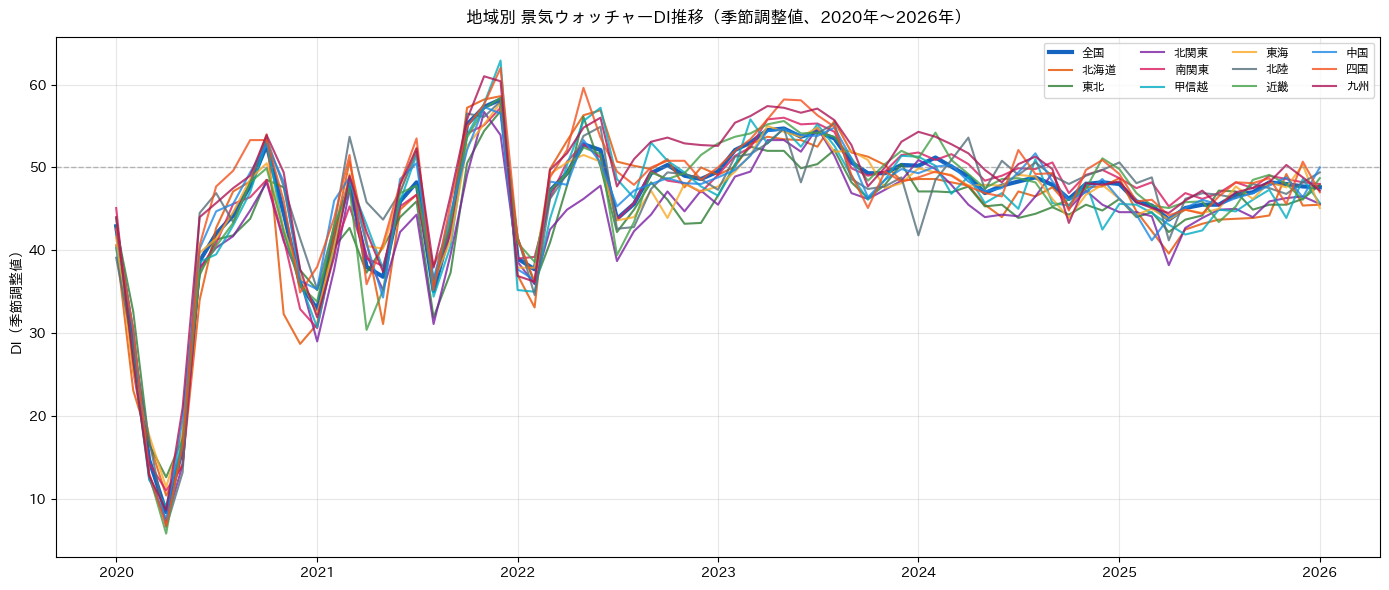

In [9]:
### 5-1. 地域別DI推移（季節調整値）
df_reg = w5['地域別現状']
regions = ['全国', '北海道', '東北', '北関東', '南関東', '甲信越',
           '東海', '北陸', '近畿', '中国', '四国', '九州']
available_r = [r for r in regions if r in df_reg.columns]

colors_r = ['#1565C0','#E65100','#2E7D32','#7B1FA2','#D81B60',
            '#00ACC1','#F9A825','#546E7A','#43A047','#1E88E5','#F4511E','#AD1457']

cutoff2 = pd.Timestamp('2020-01-01')
df_r = df_reg[available_r].loc[cutoff2:]

fig, ax = plt.subplots(figsize=(14, 6))
for i, region in enumerate(available_r):
    lw = 3 if region == '全国' else 1.5
    alpha = 1.0 if region == '全国' else 0.8
    ax.plot(df_r.index, df_r[region].values, color=colors_r[i % len(colors_r)],
            linewidth=lw, alpha=alpha, label=region)

ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('地域別 景気ウォッチャーDI推移（季節調整値、2020年〜2026年）',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('DI（季節調整値）')
ax.legend(loc='upper right', fontsize=8.5, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

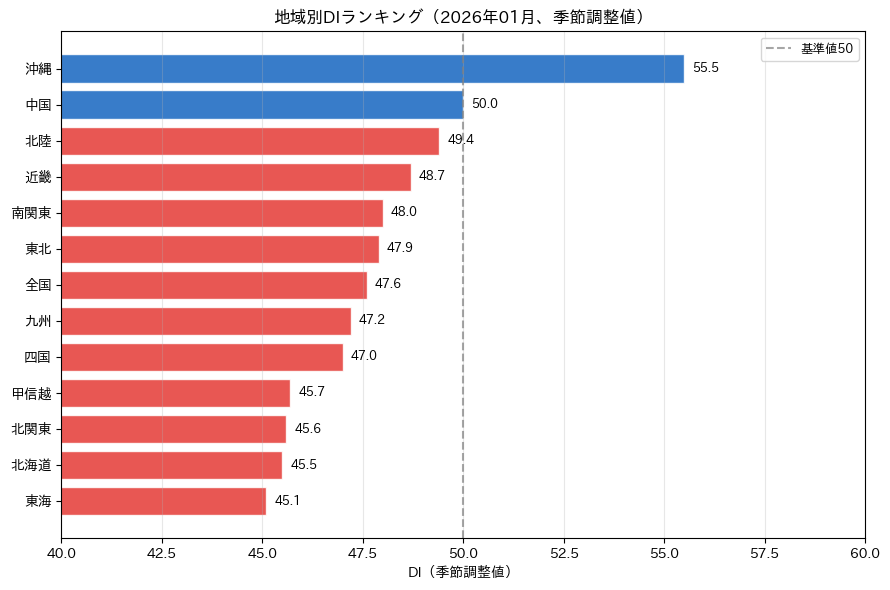

In [10]:
### 5-2. 地域別ランキング（最新月）
df_reg = w5['地域別現状']
regions_rank = ['全国','北海道','東北','北関東','南関東','甲信越',
                '東海','北陸','近畿','中国','四国','九州','沖縄']
avail_rank = [r for r in regions_rank if r in df_reg.columns]

latest_row = df_reg[avail_rank].dropna(how='all').iloc[-1]
latest_date = df_reg[avail_rank].dropna(how='all').index[-1]
ranking = latest_row.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#1565C0' if v >= 50 else '#E53935' for v in ranking.values]
bars = ax.barh(ranking.index, ranking.values, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, ranking.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2, f'{v:.1f}',
            va='center', ha='left', fontsize=9)
ax.axvline(50, color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='基準値50')
ax.set_title(f'地域別DIランキング（{latest_date.strftime("%Y年%m月")}、季節調整値）',
             fontsize=12, fontweight='bold')
ax.set_xlabel('DI（季節調整値）')
ax.legend(fontsize=9)
ax.set_xlim(40, 60)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## セクション 6: 季節調整値分析・現状vs先行き

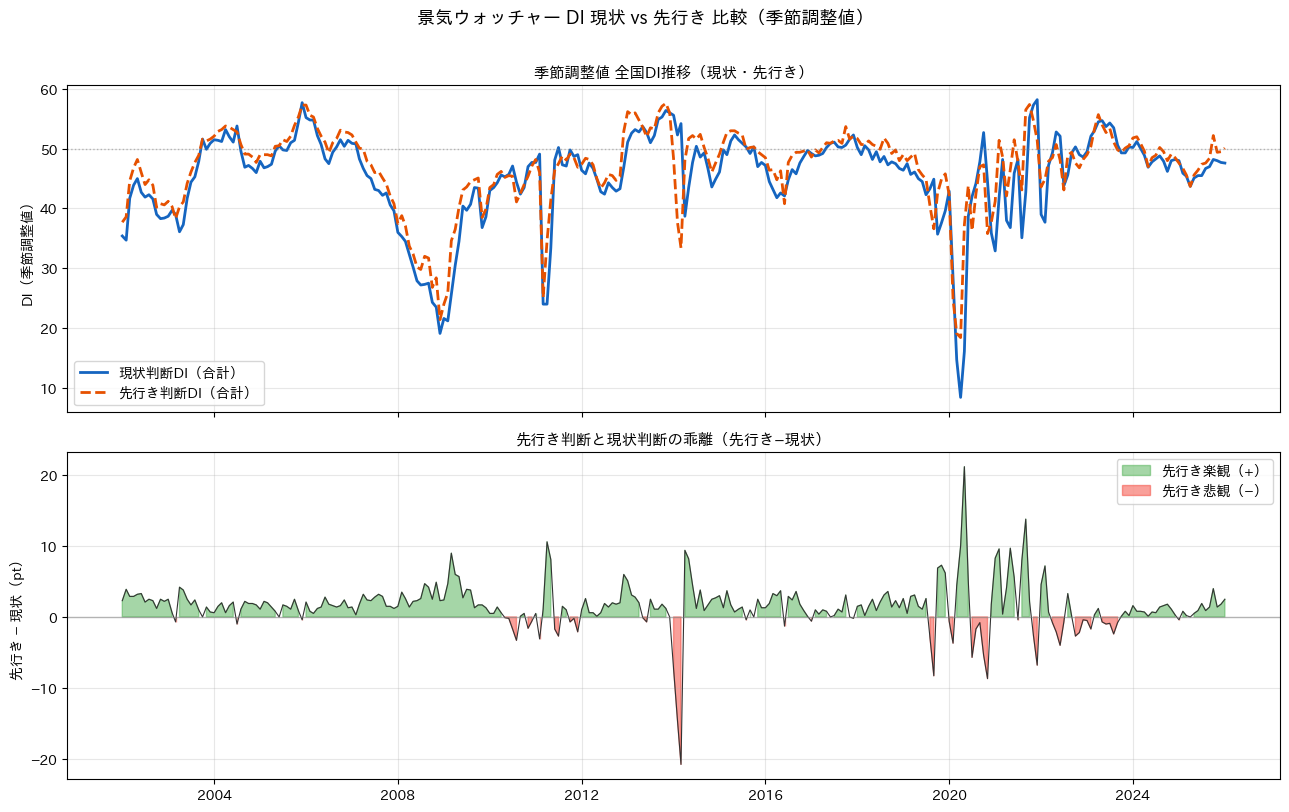


先行き−現状 ギャップ統計:
  直近値: +2.5pt（2026-01）
  直近3ヶ月平均: +1.9pt
  過去平均（全期間）: +1.5pt


In [11]:
### 6-1. 季節調整値DI（分野別現状 vs 先行き）
d_now = w5['分野別現状']
d_fwd = w5['分野別先行き']

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(d_now.index, d_now['合計'].values, color=COLORS['現状判断'],
        linewidth=2, label='現状判断DI（合計）')
ax.plot(d_fwd.index, d_fwd['合計'].values, color=COLORS['先行き判断'],
        linewidth=2, linestyle='--', label='先行き判断DI（合計）')
ax.axhline(50, color='gray', linewidth=1, linestyle=':', alpha=0.5)
ax.set_ylabel('DI（季節調整値）')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_title('季節調整値 全国DI推移（現状・先行き）', fontsize=11)

# 乖離ギャップ
gap = (d_fwd['合計'] - d_now['合計']).dropna()
ax = axes[1]
ax.fill_between(gap.index, 0, gap.values, where=gap.values > 0,
                alpha=0.5, color='#4CAF50', label='先行き楽観（+）')
ax.fill_between(gap.index, 0, gap.values, where=gap.values < 0,
                alpha=0.5, color='#F44336', label='先行き悲観（−）')
ax.plot(gap.index, gap.values, color='#333333', linewidth=0.8)
ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.set_ylabel('先行き − 現状（pt）')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_title('先行き判断と現状判断の乖離（先行き−現状）', fontsize=11)

fig.suptitle('景気ウォッチャー DI 現状 vs 先行き 比較（季節調整値）',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 統計
print(f'\n先行き−現状 ギャップ統計:')
print(f'  直近値: {gap.iloc[-1]:+.1f}pt（{gap.index[-1].strftime("%Y-%m")}）')
print(f'  直近3ヶ月平均: {gap.tail(3).mean():+.1f}pt')
print(f'  過去平均（全期間）: {gap.mean():+.1f}pt')

## セクション 7: 回答者構成比分析

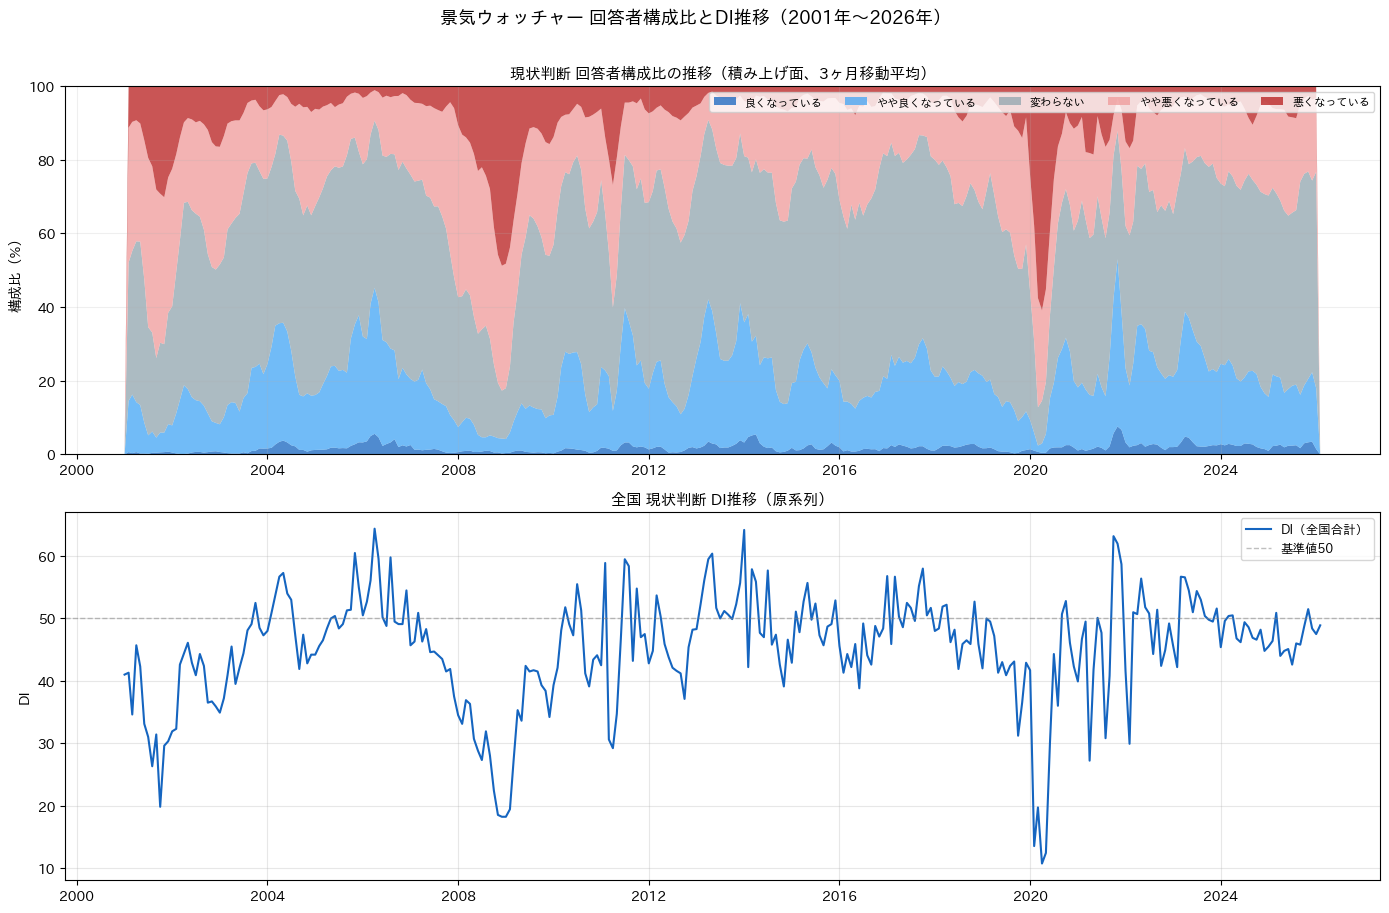

In [12]:
### 7-1. 回答構成比推移（積み上げ面グラフ）
pct_cols = ['良くなっている','やや良くなっている','変わらない','やや悪くなっている','悪くなっている']
colors5 = ['#1565C0','#42A5F5','#90A4AE','#EF9A9A','#B71C1C']

df_pct = w21[pct_cols].dropna()
df_smooth = df_pct.rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.stackplot(df_smooth.index,
             [df_smooth[c].fillna(0).values for c in pct_cols],
             labels=pct_cols, colors=colors5, alpha=0.75)
ax.set_ylabel('構成比（%）')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=8, ncol=5)
ax.set_title('現状判断 回答者構成比の推移（積み上げ面、3ヶ月移動平均）', fontsize=11)
ax.grid(alpha=0.2)

ax = axes[1]
ax.plot(w21.index, w21['DI'].values, color=COLORS['現状判断'],
        linewidth=1.5, label='DI（全国合計）')
ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='基準値50')
ax.set_ylabel('DI')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title('全国 現状判断 DI推移（原系列）', fontsize=11)

fig.suptitle('景気ウォッチャー 回答者構成比とDI推移（2001年〜2026年）',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

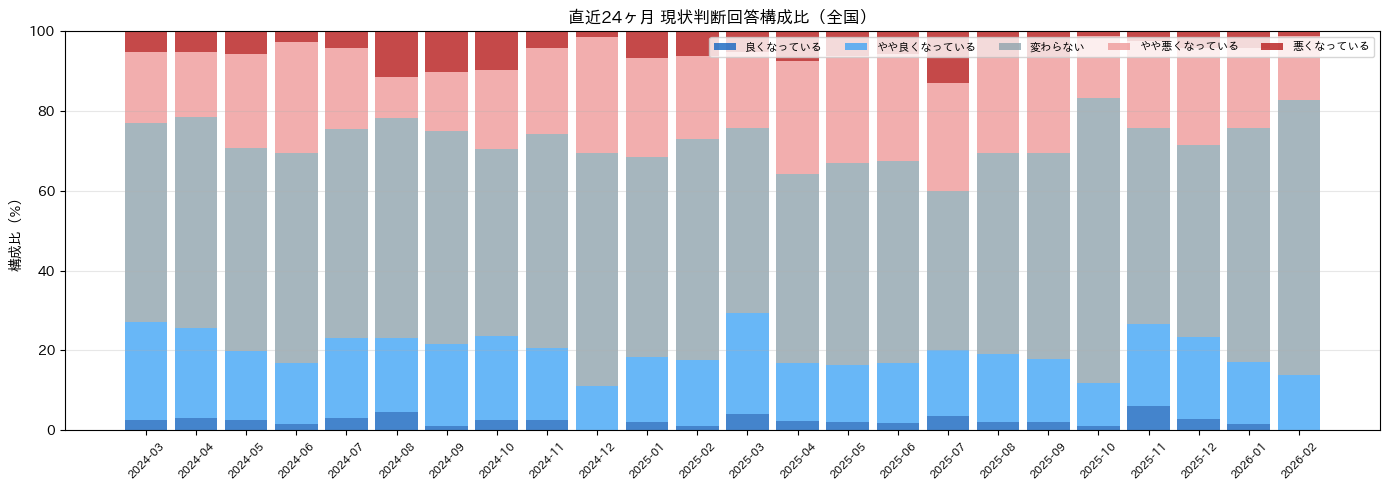

In [13]:
### 7-2. 直近24ヶ月の構成比詳細
df_24 = w21[pct_cols + ['DI']].tail(24).copy()
df_24.index = df_24.index.strftime('%Y-%m')
df_24 = df_24.round(1)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_24))
bottoms = np.zeros(len(df_24))
for i, (col, color) in enumerate(zip(pct_cols, colors5)):
    vals = df_24[col].fillna(0).values
    ax.bar(x, vals, bottom=bottoms, label=col, color=color, alpha=0.8, width=0.85)
    bottoms += vals

ax.set_xticks(list(x))
ax.set_xticklabels(df_24.index, rotation=45, fontsize=8)
ax.set_ylabel('構成比（%）')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=8, ncol=5)
ax.set_title('直近24ヶ月 現状判断回答構成比（全国）', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## セクション 8: 業種別・地域別 年次ヒートマップ

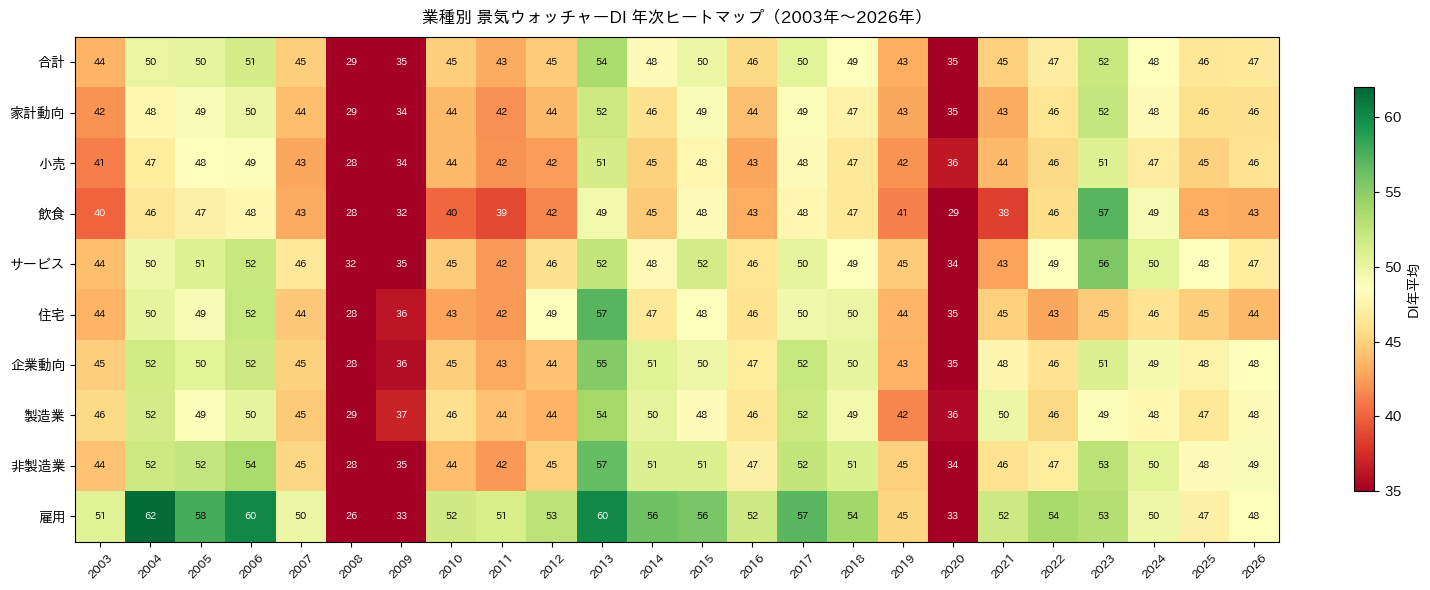

In [14]:
### 8-1. 業種別DI 年次ヒートマップ
industry_cols = ['合計','家計動向','小売','飲食','サービス','住宅','企業動向','製造業','非製造業','雇用']
df_ind = w3['現状判断']
available_i = [c for c in industry_cols if c in df_ind.columns]
df_annual_i = df_ind[available_i].resample('YE').mean().round(1)
df_annual_i.index = df_annual_i.index.year
df_annual_i = df_annual_i.loc[2003:]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(df_annual_i.T.values, aspect='auto', cmap='RdYlGn', vmin=35, vmax=62)
plt.colorbar(im, ax=ax, label='DI年平均', shrink=0.8)
ax.set_yticks(range(len(available_i)))
ax.set_yticklabels(available_i, fontsize=10)
ax.set_xticks(range(len(df_annual_i.index)))
ax.set_xticklabels([str(y) for y in df_annual_i.index], rotation=45, fontsize=8.5)
for i, col in enumerate(available_i):
    for j, year in enumerate(df_annual_i.index):
        v = df_annual_i.loc[year, col]
        if not np.isnan(v):
            tc = 'black' if 40 < v < 58 else 'white'
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7, color=tc)
ax.set_title('業種別 景気ウォッチャーDI 年次ヒートマップ（2003年〜2026年）',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

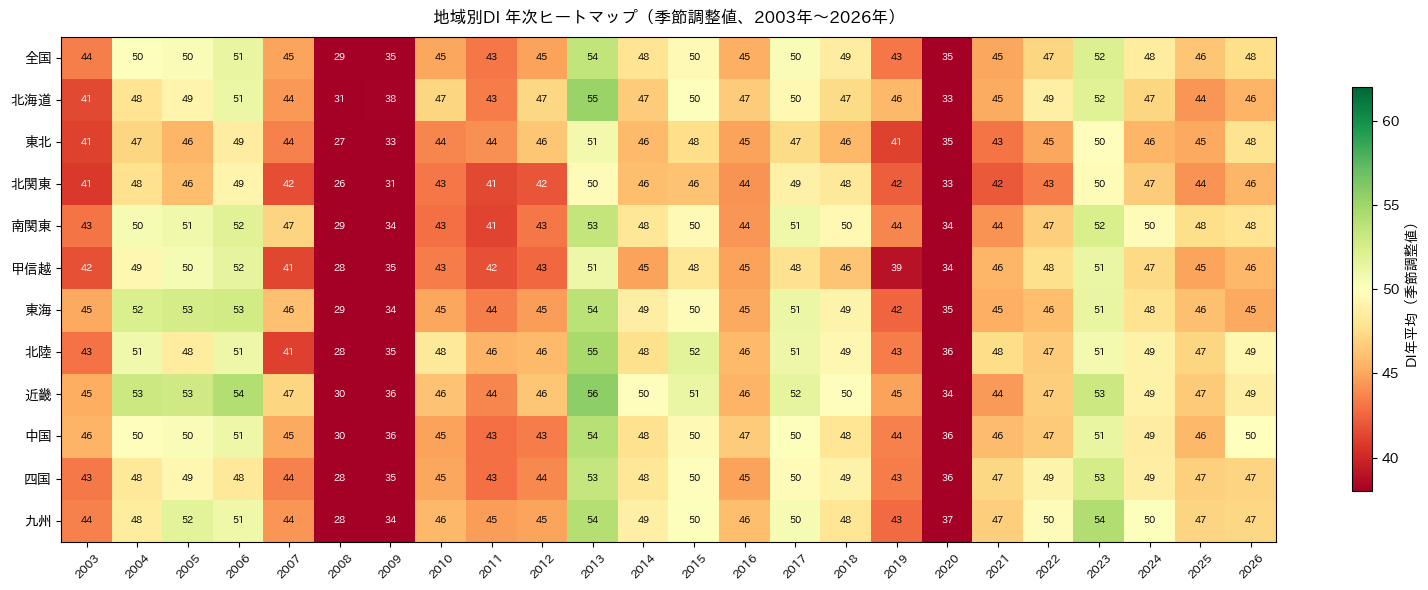

In [15]:
### 8-2. 地域別DI 年次ヒートマップ（季節調整値）
df_reg = w5['地域別現状']
region_list = ['全国','北海道','東北','北関東','南関東','甲信越',
               '東海','北陸','近畿','中国','四国','九州']
avail_reg = [r for r in region_list if r in df_reg.columns]
df_annual_r = df_reg[avail_reg].resample('YE').mean().round(1)
df_annual_r.index = df_annual_r.index.year
df_annual_r = df_annual_r.loc[2003:]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(df_annual_r.T.values, aspect='auto', cmap='RdYlGn', vmin=38, vmax=62)
plt.colorbar(im, ax=ax, label='DI年平均（季節調整値）', shrink=0.8)
ax.set_yticks(range(len(avail_reg)))
ax.set_yticklabels(avail_reg, fontsize=10)
ax.set_xticks(range(len(df_annual_r.index)))
ax.set_xticklabels([str(y) for y in df_annual_r.index], rotation=45, fontsize=8.5)
for i, reg in enumerate(avail_reg):
    for j, year in enumerate(df_annual_r.index):
        v = df_annual_r.loc[year, reg]
        if not np.isnan(v):
            tc = 'black' if 42 < v < 58 else 'white'
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7, color=tc)
ax.set_title('地域別DI 年次ヒートマップ（季節調整値、2003年〜2026年）',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## セクション 9: 直近トレンド詳細（2024年〜2026年）

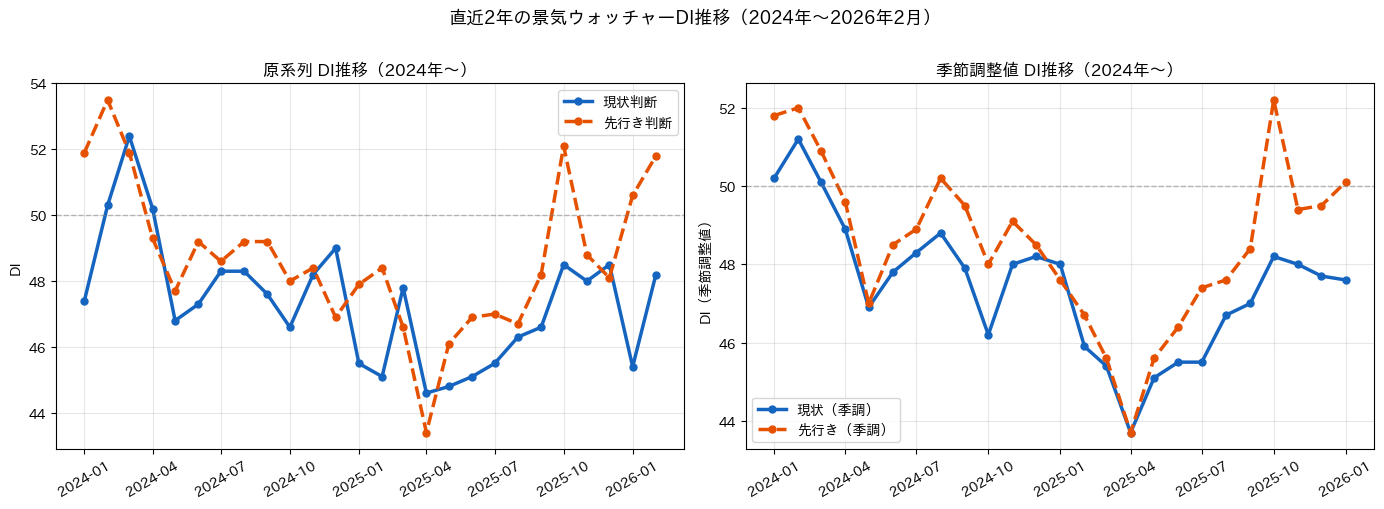

In [16]:
### 9-1. 直近2年DI推移（原系列 vs 季節調整値）
cutoff_r = pd.Timestamp('2024-01-01')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color, ls in [('現状判断',COLORS['現状判断'],'-'),('先行き判断',COLORS['先行き判断'],'--')]:
    s = w3[label]['合計'].loc[cutoff_r:].dropna()
    ax.plot(s.index, s.values, color=color, linestyle=ls, linewidth=2.5,
            marker='o', markersize=5, label=label)
ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('原系列 DI推移（2024年〜）', fontsize=12, fontweight='bold')
ax.set_ylabel('DI')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
for key, label, color, ls in [
    ('分野別現状','現状（季調）',COLORS['現状判断'],'-'),
    ('分野別先行き','先行き（季調）',COLORS['先行き判断'],'--'),
]:
    if key in w5:
        s = w5[key]['合計'].loc[cutoff_r:].dropna()
        ax.plot(s.index, s.values, color=color, linestyle=ls, linewidth=2.5,
                marker='o', markersize=5, label=label)
ax.axhline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('季節調整値 DI推移（2024年〜）', fontsize=12, fontweight='bold')
ax.set_ylabel('DI（季節調整値）')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

fig.suptitle('直近2年の景気ウォッチャーDI推移（2024年〜2026年2月）',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
### 9-2. 直近データ詳細テーブル
print('=== 直近12ヶ月の現状・先行き・水準DI ===')
recent_all = pd.DataFrame({
    '現状判断': w3['現状判断']['合計'],
    '先行き判断': w3['先行き判断']['合計'],
    '水準DI': w3['水準']['合計'],
    '現状（季調）': w5.get('分野別現状', pd.DataFrame()).get('合計', pd.Series()),
    '先行き（季調）': w5.get('分野別先行き', pd.DataFrame()).get('合計', pd.Series()),
}).tail(12).round(1)
recent_all.index = recent_all.index.strftime('%Y-%m')
display(recent_all)

=== 直近12ヶ月の現状・先行き・水準DI ===


,現状判断,先行き判断,水準DI,現状（季調）,先行き（季調）
date,,,,,
2025-03,47.8,46.6,46.9,45.4,45.6
2025-04,44.6,43.4,44.6,43.7,43.7
2025-05,44.8,46.1,44.2,45.1,45.6
2025-06,45.1,46.9,44.8,45.5,46.4
2025-07,45.5,47.0,44.7,45.5,47.4
2025-08,46.3,46.7,45.3,46.7,47.6
2025-09,46.6,48.2,44.9,47.0,48.4
2025-10,48.5,52.1,47.1,48.2,52.2
2025-11,48.0,48.8,46.9,48.0,49.4


## セクション 10: 総合考察と政策的示唆

In [18]:
### 10-1. 主要知見まとめ
findings = {
    'DI現状（2026年2月）': '48.9（季節調整値）/ 前月比+1.3pt',
    'DI先行き（2026年2月）': '50.0（季節調整値）/ 前月比-0.1pt',
    '基調判断': '持ち直している',
    '改善要因': '天候回復（1月寒波の影響剥落）、サービス・飲食関連の回復',
    'リスク要因': '4月以降の値上げ、労務費上昇、米国関税リスク',
}

print('=== 2026年2月 景気ウォッチャー調査 主要知見 ===')
for k, v in findings.items():
    print(f'  {k}: {v}')

=== 2026年2月 景気ウォッチャー調査 主要知見 ===
  DI現状（2026年2月）: 48.9（季節調整値）/ 前月比+1.3pt
  DI先行き（2026年2月）: 50.0（季節調整値）/ 前月比-0.1pt
  基調判断: 持ち直している
  改善要因: 天候回復（1月寒波の影響剥落）、サービス・飲食関連の回復
  リスク要因: 4月以降の値上げ、労務費上昇、米国関税リスク


In [19]:
### 10-2. 長期トレンド考察

# 年平均DI の変化率
df_y = w3['現状判断']['合計'].resample('YE').mean()
df_y.index = df_y.index.year
recent_5y = df_y.tail(5)

print('=== 直近5年の年平均DI推移 ===')
for year, val in recent_5y.items():
    prev = df_y.get(year - 1, np.nan)
    chg = val - prev if not np.isnan(prev) else np.nan
    print(f'  {year}年: {val:.1f}' + (f' ({chg:+.1f}pt)' if not np.isnan(chg) else ''))

print()
# コロナ前後比較
pre_covid = df_y.loc[2018:2019].mean()
post_covid = df_y.loc[2021:2023].mean()
print(f'コロナ前（2018-2019）平均DI: {pre_covid:.1f}')
print(f'コロナ後（2021-2023）平均DI: {post_covid:.1f}')
print(f'差: {post_covid - pre_covid:+.1f}pt')

# 2026年直近
latest_di = w5.get('分野別現状', pd.DataFrame()).get('合計', pd.Series())
if not latest_di.empty:
    print(f'\n2026年最新値: {latest_di.iloc[-1]:.1f}（{latest_di.index[-1].strftime("%Y-%m")}）')

=== 直近5年の年平均DI推移 ===
  2022年: 47.0 (+2.0pt)
  2023年: 52.0 (+5.0pt)
  2024年: 48.5 (-3.5pt)
  2025年: 46.4 (-2.2pt)
  2026年: 46.8 (+0.4pt)

コロナ前（2018-2019）平均DI: 46.0
コロナ後（2021-2023）平均DI: 48.0
差: +2.1pt

2026年最新値: 47.6（2026-01）


In [20]:
### 10-3. 地域格差分析
df_reg = w5['地域別現状']
region_list2 = ['北海道','東北','北関東','南関東','甲信越','東海','北陸','近畿','中国','四国','九州']
avail_r2 = [r for r in region_list2 if r in df_reg.columns]

# 直近12ヶ月平均
recent_12 = df_reg[avail_r2].tail(12).mean().sort_values(ascending=False)
print('=== 地域別 直近12ヶ月平均DI（季節調整値）===')
for region, val in recent_12.items():
    bar = '■' * int((val - 40) * 2)
    print(f'  {region:6s}: {val:.1f} {bar}')

print(f'\n地域格差（最大−最小）: {recent_12.max() - recent_12.min():.1f}pt')
print(f'最高: {recent_12.idxmax()}（{recent_12.max():.1f}）')
print(f'最低: {recent_12.idxmin()}（{recent_12.min():.1f}）')

=== 地域別 直近12ヶ月平均DI（季節調整値）===
  南関東   : 47.5 ■■■■■■■■■■■■■■■
  北陸    : 47.0 ■■■■■■■■■■■■■■
  九州    : 46.9 ■■■■■■■■■■■■■
  四国    : 46.7 ■■■■■■■■■■■■■
  近畿    : 46.5 ■■■■■■■■■■■■■
  東海    : 46.0 ■■■■■■■■■■■■
  中国    : 46.0 ■■■■■■■■■■■■
  東北    : 45.2 ■■■■■■■■■■
  甲信越   : 44.9 ■■■■■■■■■
  北関東   : 44.3 ■■■■■■■■
  北海道   : 44.0 ■■■■■■■■

地域格差（最大−最小）: 3.5pt
最高: 南関東（47.5）
最低: 北海道（44.0）


In [21]:
### 10-4. 総合分析まとめ（テキスト）
summary = '''
【景気ウォッチャー調査 総合分析まとめ（2026年3月時点）】

■ 現状
2026年2月の景気ウォッチャーDI（現状判断・季節調整値）は48.9。4ヶ月ぶりに上昇したが、
基準値の50には届かず「持ち直し」の基調が続いている。天候回復を受けてサービス・飲食業が改善。

■ 構造的変化
・2020年コロナ禍でDI最低値19.4（2020年4月・原系列）を記録し急落。
・2022年以降は回復局面に入り、2023年後半から50近傍で推移。
・家計動向・企業動向・雇用の三分野が概ね同方向に動く傾向。

■ 地域差
・沖縄・東海・南関東が相対的に高水準。
・東北・北陸が中位、四国・北海道が低位に位置することが多い。
・格差は概ね5〜8pt程度で、構造的な差は縮小傾向にある。

■ 先行きリスク
・値上げラッシュ（4月〜）が家計消費を圧迫するリスク。
・米国関税政策の不確実性が企業マインドに影響。
・人手不足・賃上げコストが中小企業の収益圧迫要因に。

■ データの限界
・本調査は主観的評価であり、速報性は高いが客観的指標と乖離する場合がある。
・回答者構成は業種・地域により固定されており、産業構造変化を反映しにくい。
'''
print(summary)


【景気ウォッチャー調査 総合分析まとめ（2026年3月時点）】

■ 現状
2026年2月の景気ウォッチャーDI（現状判断・季節調整値）は48.9。4ヶ月ぶりに上昇したが、
基準値の50には届かず「持ち直し」の基調が続いている。天候回復を受けてサービス・飲食業が改善。

■ 構造的変化
・2020年コロナ禍でDI最低値19.4（2020年4月・原系列）を記録し急落。
・2022年以降は回復局面に入り、2023年後半から50近傍で推移。
・家計動向・企業動向・雇用の三分野が概ね同方向に動く傾向。

■ 地域差
・沖縄・東海・南関東が相対的に高水準。
・東北・北陸が中位、四国・北海道が低位に位置することが多い。
・格差は概ね5〜8pt程度で、構造的な差は縮小傾向にある。

■ 先行きリスク
・値上げラッシュ（4月〜）が家計消費を圧迫するリスク。
・米国関税政策の不確実性が企業マインドに影響。
・人手不足・賃上げコストが中小企業の収益圧迫要因に。

■ データの限界
・本調査は主観的評価であり、速報性は高いが客観的指標と乖離する場合がある。
・回答者構成は業種・地域により固定されており、産業構造変化を反映しにくい。

